<a href="https://colab.research.google.com/github/amoheric/Data-Structures-and-Algorithms-with-Python/blob/main/Performance_Benchmarking_Binary_Search_Tree_vs_AVL_Tree_for_Large_Data_Sets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install memory_profiler and all needed libraires



In [6]:
!pip install memory_profiler

Key Data Structures
1. AVL Tree Implementation

In [46]:
import random # Import random module to shuffle data
import time # Import time module to measure performance
import matplotlib.pyplot as plt #  It also opens figures on your screen, and acts as the figure GUI manager.
import memory_profiler  # Importing the memory_profiler module to measure memory usage
import tracemalloc # tracing

# AVL Tree Node Implementation
class AVLNode:
    def __init__(self, key):
        # Initialize a node with a key and set its height to 1
        self.key = key
        self.left = None  # Left child of the node
        self.right = None  # Right child of the node
        self.height = 1  # Height of the node in the tree

# AVL Tree Implementation
class AVLTree:
    def __init__(self):
        # Initialize an empty AVL tree
        self.root = None

    def insert(self, key):
        """Insert a node into the AVL tree."""
        # Start the insertion from the root of the tree
        self.root = self._insert(self.root, key)

    def _insert(self, node, key):
        # Recursively insert a key into the tree
        if not node:
            return AVLNode(key)  # Create a new node if the position is empty

        if key < node.key:
            # If the key is smaller, go to the left subtree
            node.left = self._insert(node.left, key)
        elif key > node.key:
            # If the key is larger, go to the right subtree
            node.right = self._insert(node.right, key)
        else:
            return node  # Duplicate keys are not allowed

        # Update the height of the current node
        node.height = 1 + max(self._get_height(node.left), self._get_height(node.right))

        # Calculate the balance factor to check if the node is unbalanced
        balance = self._get_balance(node)

        # Perform rotations if the node becomes unbalanced
        if balance > 1 and key < node.left.key:  # Left Left case
            return self._rotate_right(node)
        if balance < -1 and key > node.right.key:  # Right Right case
            return self._rotate_left(node)
        if balance > 1 and key > node.left.key:  # Left Right case
            node.left = self._rotate_left(node.left)
            return self._rotate_right(node)
        if balance < -1 and key < node.right.key:  # Right Left case
            node.right = self._rotate_right(node.right)
            return self._rotate_left(node)

        return node  # Return the updated node

    def delete(self, key):
        """Delete a node from the AVL tree."""
        # Start the deletion process from the root of the tree
        self.root = self._delete(self.root, key)

    def _delete(self, node, key):
        # Recursively delete a key from the tree
        if not node:
            return node  # Return None if the node is not found

        if key < node.key:
            # If the key is smaller, go to the left subtree
            node.left = self._delete(node.left, key)
        elif key > node.key:
            # If the key is larger, go to the right subtree
            node.right = self._delete(node.right, key)
        else:
            # Node with one or no child
            if node.left is None:
                return node.right  # Replace node with its right child
            elif node.right is None:
                return node.left  # Replace node with its left child

            # Node with two children: Get the inorder successor
            temp = self._min_value_node(node.right)
            node.key = temp.key  # Replace node's key with the successor's key
            node.right = self._delete(node.right, temp.key)  # Delete the successor

        # Update the height of the current node
        node.height = 1 + max(self._get_height(node.left), self._get_height(node.right))

        # Calculate the balance factor to check if the node is unbalanced
        balance = self._get_balance(node)

        # Perform rotations if the node becomes unbalanced
        if balance > 1 and self._get_balance(node.left) >= 0:  # Left Left case
            return self._rotate_right(node)
        if balance > 1 and self._get_balance(node.left) < 0:  # Left Right case
            node.left = self._rotate_left(node.left)
            return self._rotate_right(node)
        if balance < -1 and self._get_balance(node.right) <= 0:  # Right Right case
            return self._rotate_left(node)
        if balance < -1 and self._get_balance(node.right) > 0:  # Right Left case
            node.right = self._rotate_right(node.right)
            return self._rotate_left(node)

        return node  # Return the updated node

    def _min_value_node(self, node):
        """Helper to find the smallest node in a subtree."""
        current = node
        # Traverse the left subtree to find the minimum value
        while current.left:
            current = current.left
        return current

    def _rotate_left(self, z):
        # Perform a left rotation to balance the tree
        y = z.right
        T2 = y.left

        # Perform the rotation
        y.left = z
        z.right = T2

        # Update heights
        z.height = 1 + max(self._get_height(z.left), self._get_height(z.right))
        y.height = 1 + max(self._get_height(y.left), self._get_height(y.right))

        return y  # Return the new root

    def _rotate_right(self, z):
        # Perform a right rotation to balance the tree
        y = z.left
        T3 = y.right

        # Perform the rotation
        y.right = z
        z.left = T3

        # Update heights
        z.height = 1 + max(self._get_height(z.left), self._get_height(z.right))
        y.height = 1 + max(self._get_height(y.left), self._get_height(y.right))

        return y  # Return the new root

    def _get_height(self, node):
        # Return the height of a node, or 0 if the node is None
        return node.height if node else 0

    def _get_balance(self, node):
        # Calculate the balance factor of a node
        return self._get_height(node.left) - self._get_height(node.right)


2. BST Node and BST Class

In [47]:
# Binary Search Tree Node Implementation
class Node:
    def __init__(self, key):
        # Initialize a node with a key
        self.key = key
        self.left = None  # Left child of the node
        self.right = None  # Right child of the node

# Binary Search Tree Implementation
class BinarySearchTree:
    def __init__(self):
        # Initialize an empty BST
        self.root = None

    def insert(self, key):
        """Insert a node into the BST."""
        if self.root is None:
            # If the tree is empty, set the root to the new node
            self.root = Node(key)
        else:
            # Otherwise, insert the node recursively
            self._insert(self.root, key)

    def _insert(self, node, key):
        # Recursively insert a key into the BST
        if key < node.key:
            # If the key is smaller, go to the left subtree
            if node.left is None:
                node.left = Node(key)  # Create a new node if the position is empty
            else:
                self._insert(node.left, key)  # Recursively call for the left child
        elif key > node.key:
            # If the key is larger, go to the right subtree
            if node.right is None:
                node.right = Node(key)  # Create a new node if the position is empty
            else:
                self._insert(node.right, key)  # Recursively call for the right child

    def delete(self, key):
        """Delete a node from the BST."""
        self.root = self._delete(self.root, key)  # Start deletion from the root

    def _delete(self, node, key):
        # Recursively delete a key from the BST
        if not node:
            return node  # If the node is not found, return None

        if key < node.key:
            # If the key is smaller, go to the left subtree
            node.left = self._delete(node.left, key)
        elif key > node.key:
            # If the key is larger, go to the right subtree
            node.right = self._delete(node.right, key)
        else:
            # Node with one or no child
            if node.left is None:
                return node.right  # Replace node with its right child
            elif node.right is None:
                return node.left  # Replace node with its left child

            # Node with two children: Get the inorder successor
            temp = self._min_value_node(node.right)
            node.key = temp.key  # Replace node's key with the successor's key
            node.right = self._delete(node.right, temp.key)  # Delete the successor

        return node  # Return the updated node

    def _min_value_node(self, node):
        """Helper to find the smallest node in a subtree."""
        current = node
        # Traverse the left subtree to find the minimum value
        while current.left:
            current = current.left
        return current

    def traverse(self, order='inorder'):
        """Traverse the tree in the specified order."""
        result = []
        if order == 'inorder':
            # Inorder traversal: Left -> Root -> Right
            self._inorder(self.root, result)
        elif order == 'preorder':
            # Preorder traversal: Root -> Left -> Right
            self._preorder(self.root, result)
        elif order == 'postorder':
            # Postorder traversal: Left -> Right -> Root
            self._postorder(self.root, result)
        return result

    def _inorder(self, node, result):
        if node:
            # Recursively traverse the left subtree
            self._inorder(node.left, result)
            result.append(node.key)  # Visit the root
            # Recursively traverse the right subtree
            self._inorder(node.right, result)

    def _preorder(self, node, result):
        if node:
            result.append(node.key)  # Visit the root
            # Recursively traverse the left subtree
            self._preorder(node.left, result)
            # Recursively traverse the right subtree
            self._preorder(node.right, result)

    def _postorder(self, node, result):
        if node:
            # Recursively traverse the left subtree
            self._postorder(node.left, result)
            # Recursively traverse the right subtree
            self._postorder(node.right, result)
            result.append(node.key)  # Visit the root


3. Performance Analysis

Testing and Timing

In [48]:

def measure_performance(tree_class, num_nodes):
    """
    Measure the performance of a tree class for insertion and deletion.
    """
    tree = tree_class()  # Create an instance of the tree class
    data = list(range(num_nodes))  # Generate a list of numbers from 0 to num_nodes-1
    random.shuffle(data)  # Shuffle the data to prevent unbalanced trees

    # Measure insertion time
    start_time = time.time()  # Record the start time
    for value in data:
        tree.insert(value)  # Insert each value into the tree
    insert_time = time.time() - start_time  # Calculate the time taken for insertion

    # Measure deletion time
    start_time = time.time()  # Record the start time
    for value in data:
        tree.delete(value)  # Delete each value from the tree
    delete_time = time.time() - start_time  # Calculate the time taken for deletion

    return insert_time, delete_time  # Return the times for insertion and deletion


4. Execution and Data Collection

In [49]:
# Define the sizes of data to test the performance
sizes = [100, 1000, 10000, 100000]  # Test for different sizes of data
bst_results = []  # To store the results for BinarySearchTree
avl_results = []  # To store the results for AVLTree

# Measure performance for each size
for size in sizes:
    print(f"Testing for {size} nodes...")  # Log the progress
    bst_insert, bst_delete = measure_performance(BinarySearchTree, size)  # Measure for BST
    avl_insert, avl_delete = measure_performance(AVLTree, size)  # Measure for AVL
    bst_results.append((bst_insert, bst_delete))  # Append the BST results
    avl_results.append((avl_insert, avl_delete))  # Append the AVL results


Testing for 100 nodes...
Testing for 1000 nodes...
Testing for 10000 nodes...
Testing for 100000 nodes...


5. Tree Performance Tables

In [50]:
# Main Function
if __name__ == "__main__":
    # Define node counts for testing
    node_counts = [100, 1000, 10000, 100000]

    print("\n\n Measuring Binary Search Tree (BST) performance...")
    bst_results = []
    for n in node_counts:
        insert_time, delete_time = measure_performance(BinarySearchTree, n)
        bst_results.append((n, insert_time, delete_time))

    # Print results for BST
    print("\n\n BST Performance:")
    print("----------------")
    print(f"| {'Num Nodes':^10} | {'Insert Time':^12} | {'Delete Time':^12} |")
    print("|" + "-" * 11 + "|" + "-" * 13 + "|" + "-" * 13 + "|")
    for n, insert_time, delete_time in bst_results:
        print(f"| {n:^10} | {insert_time:^12.6f} | {delete_time:^12.6f} |")

    print("\n\n Measuring AVL Tree performance...")
    avl_results = []
    for n in node_counts:
        insert_time, delete_time = measure_performance(AVLTree, n)
        avl_results.append((n, insert_time, delete_time))

    # Print results for AVL Tree
    print("\n\n AVL Tree Performance:")
    print("---------------------")
    print(f"| {'Num Nodes':^10} | {'Insert Time':^12} | {'Delete Time':^12} |")
    print("|" + "-" * 11 + "|" + "-" * 13 + "|" + "-" * 13 + "|")
    for n, insert_time, delete_time in avl_results:
        print(f"| {n:^10} | {insert_time:^12.6f} | {delete_time:^12.6f} |")



 Measuring Binary Search Tree (BST) performance...


 BST Performance:
----------------
| Num Nodes  | Insert Time  | Delete Time  |
|-----------|-------------|-------------|
|    100     |   0.000340   |   0.000281   |
|    1000    |   0.003774   |   0.003863   |
|   10000    |   0.045839   |   0.046753   |
|   100000   |   1.142006   |   0.885077   |


 Measuring AVL Tree performance...


 AVL Tree Performance:
---------------------
| Num Nodes  | Insert Time  | Delete Time  |
|-----------|-------------|-------------|
|    100     |   0.000832   |   0.000681   |
|    1000    |   0.014720   |   0.012995   |
|   10000    |   0.200686   |   0.178027   |
|   100000   |   2.937809   |   3.033611   |


6. Visualization of Results

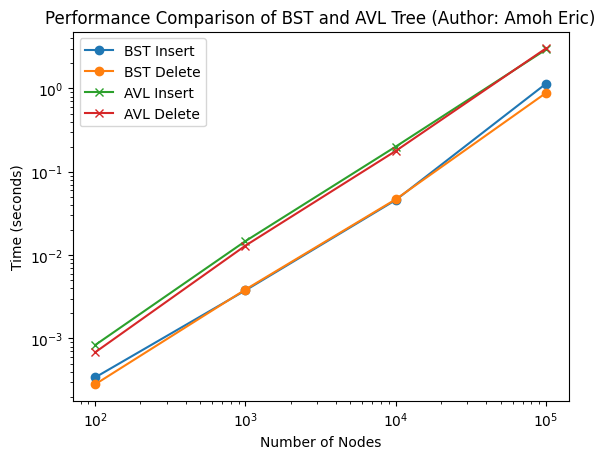

<Figure size 1000x500 with 0 Axes>

In [51]:
import matplotlib.pyplot as plt  # Import matplotlib for visualization

# Extract the insertion and deletion times from the results
bst_insert_times = [x[1] for x in bst_results]  # BST insertion times
bst_delete_times = [x[2] for x in bst_results]  # BST deletion times
avl_insert_times = [x[1] for x in avl_results]  # AVL insertion times
avl_delete_times = [x[2] for x in avl_results]  # AVL deletion times

# Plot the results
plt.plot(sizes, bst_insert_times, 'o-', label="BST Insert")  # Plot BST insertion times
plt.plot(sizes, bst_delete_times, 'o-', label="BST Delete")  # Plot BST deletion times
plt.plot(sizes, avl_insert_times, 'x-', label="AVL Insert")  # Plot AVL insertion times
plt.plot(sizes, avl_delete_times, 'x-', label="AVL Delete")  # Plot AVL deletion times

# Set the scale to logarithmic for better visualization
plt.xscale("log")  # Logarithmic scale for x-axis
plt.yscale("log")  # Logarithmic scale for y-axis

# Label the axes and set the title
plt.xlabel("Number of Nodes")  # Label for x-axis
plt.ylabel("Time (seconds)")  # Label for y-axis
plt.title("Performance Comparison of BST and AVL Tree (Author: Amoh Eric)")  # Title of the plot

# Add a legend to identify the lines
plt.legend() # Plot Legend /map
plt.figure(figsize=(10, 5)) # Sets the figure size

# Display the plot
plt.show()
